In [80]:
import pandas as pd

# Load dataset
df = pd.read_csv("bank-full.csv", sep=";")


In [81]:
# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()


In [82]:
df = df.rename(columns={
    "y": "target",
    "job": "job_type",
    "marital": "marital_status",
    "education": "education_level",
    "default": "credit_default",
    "housing": "housing_loan",
    "loan": "personal_loan",
    "contact": "contact_type",
    "duration": "call_duration",
    "campaign": "contact_count",
    "pdays": "days_since_last_contact",
    "previous": "previous_contacts",
    "poutcome": "previous_campaign_outcome"
})


In [83]:
print("Dataset shape:", df.shape)


Dataset shape: (45211, 17)


In [84]:
# Count duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Shape after removal
print("Shape after removing duplicates:", df.shape)


Duplicate rows: 0
Shape after removing duplicates: (45211, 17)


In [85]:
# Check null values per column
print(df.isnull().sum())


age                          0
job_type                     0
marital_status               0
education_level              0
credit_default               0
balance                      0
housing_loan                 0
personal_loan                0
contact_type                 0
day                          0
month                        0
call_duration                0
contact_count                0
days_since_last_contact      0
previous_contacts            0
previous_campaign_outcome    0
target                       0
dtype: int64


In [86]:
# Total null values
print("Total null values:", df.isnull().sum().sum())


Total null values: 0


In [87]:
# Convert target to binary
df["target"] = df["target"].map({"yes": 1, "no": 0})


In [88]:
# Drop call duration to avoid data leakage
df = df.drop(columns=["call_duration"])


In [89]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   age                        45211 non-null  int64 
 1   job_type                   45211 non-null  object
 2   marital_status             45211 non-null  object
 3   education_level            45211 non-null  object
 4   credit_default             45211 non-null  object
 5   balance                    45211 non-null  int64 
 6   housing_loan               45211 non-null  object
 7   personal_loan              45211 non-null  object
 8   contact_type               45211 non-null  object
 9   day                        45211 non-null  int64 
 10  month                      45211 non-null  object
 11  contact_count              45211 non-null  int64 
 12  days_since_last_contact    45211 non-null  int64 
 13  previous_contacts          45211 non-null  int64 
 14  previo

In [90]:
# Summary statistics
df.describe()


,age,balance,day,contact_count,days_since_last_contact,previous_contacts,target
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,2.763841,40.197828,0.580323,0.116985
std,10.618762,3044.765829,8.322476,3.098021,100.128746,2.303441,0.321406
min,18.000000,-8019.000000,1.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,72.000000,8.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,448.000000,16.000000,2.000000,-1.000000,0.000000,0.000000
75%,48.000000,1428.000000,21.000000,3.000000,-1.000000,0.000000,0.000000
max,95.000000,102127.000000,31.000000,63.000000,871.000000,275.000000,1.000000


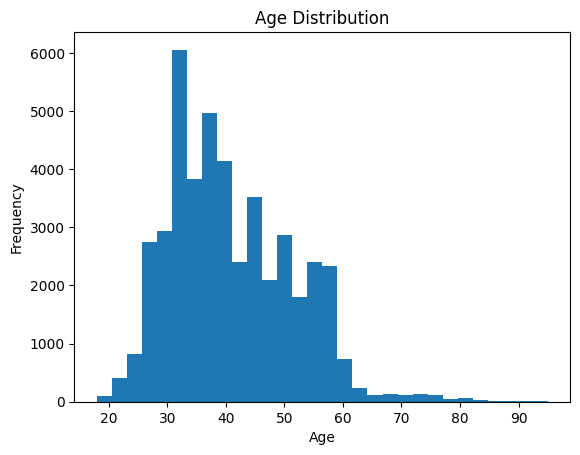

In [91]:
import matplotlib.pyplot as plt

plt.hist(df["age"], bins=30)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()


In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count of target classes
df["target"].value_counts()


,count
target,
0,39922
1,5289


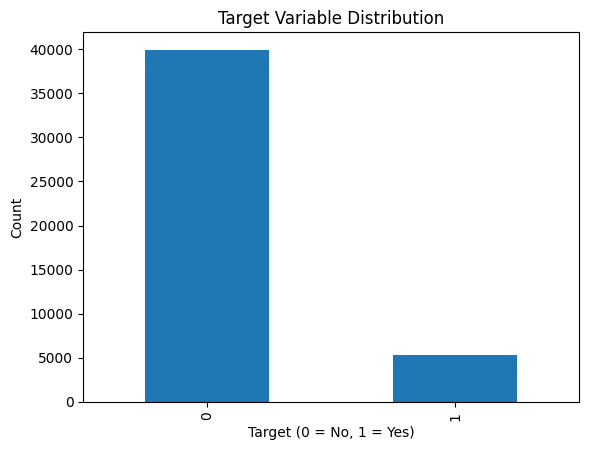

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. Target variable distribution
# -------------------------------

# Count of subscription outcomes
df["target"].value_counts()

plt.figure()
# Bar plot to show class imbalance
df["target"].value_counts().plot(kind="bar")
plt.xlabel("Target (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Target Variable Distribution")
plt.show()


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


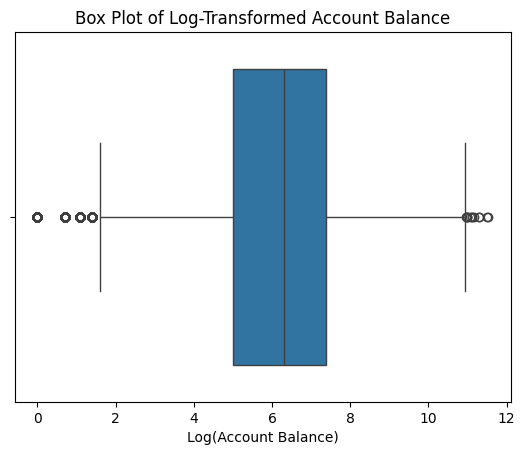

In [94]:
# -------------------------------
# 3. Box plot for outliers (Balance)
# -------------------------------

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
# Log-transform balance (add 1 to avoid log(0))
sns.boxplot(x=np.log1p(df["balance"]))
plt.xlabel("Log(Account Balance)")
plt.title("Box Plot of Log-Transformed Account Balance")
plt.show()


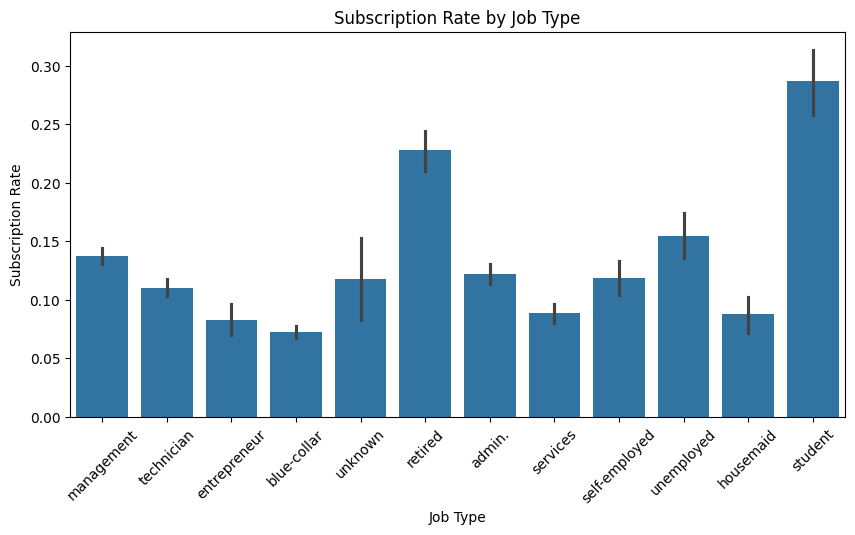

In [71]:
# -------------------------------
# 4. Job type vs subscription rate
# -------------------------------

plt.figure(figsize=(10,5))
# Bar plot showing average subscription rate per job type
sns.barplot(
    x="job_type",
    y="target",
    data=df,
    estimator=lambda x: sum(x) / len(x)
)
plt.xticks(rotation=45)
plt.xlabel("Job Type")
plt.ylabel("Subscription Rate")
plt.title("Subscription Rate by Job Type")
plt.show()

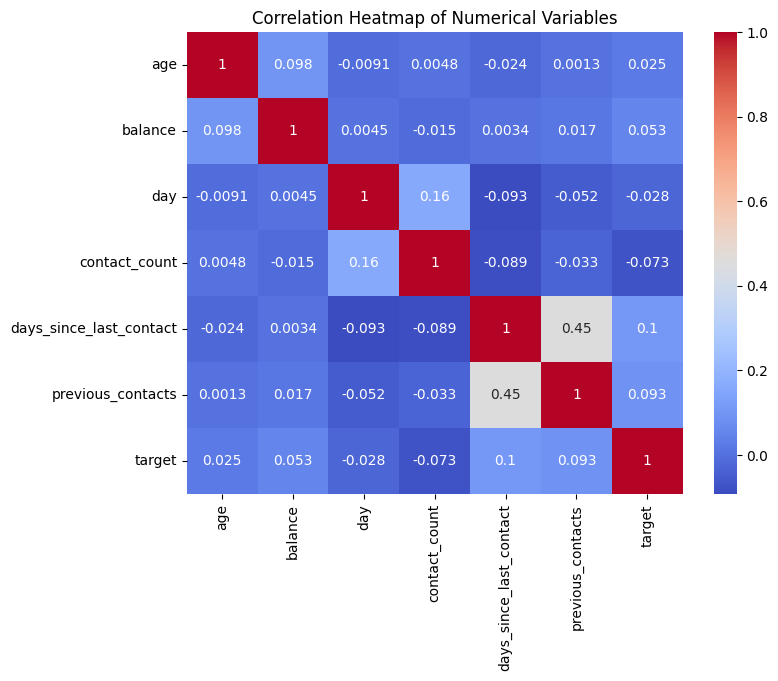

In [72]:
# -------------------------------
# 5. Correlation heatmap
# -------------------------------

plt.figure(figsize=(8,6))
# Select only numerical columns for correlation
numeric_cols = df.select_dtypes(include=["int64", "float64"])

# Heatmap to visualize correlations between numerical features
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [73]:
# ------------------------------------------------
# Import required libraries
# ------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# ------------------------------------------------
# Separate features and target
# ------------------------------------------------

X = df.drop("target", axis=1)   # Features
y = df["target"]               # Target variable



In [74]:
# ------------------------------------------------
# Label encoding for categorical variables
# ------------------------------------------------

# Identify categorical columns
categorical_cols = X.select_dtypes(include="object").columns

# Apply LabelEncoder to each categorical column
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le   # Store encoder for future use


In [75]:
# ------------------------------------------------
# Train-test split (stratified)
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y   # Preserve class imbalance
)


In [76]:
# ------------------------------------------------
# Standard scaling for numerical features
# ------------------------------------------------

# Identify numerical columns
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data and transform both sets
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])


In [77]:
# ------------------------------------------------
# Apply SMOTE to handle class imbalance
# ------------------------------------------------

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE only on training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [78]:
# ------------------------------------------------
# Check class distribution after SMOTE
# ------------------------------------------------

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


Before SMOTE:
target
0    31937
1     4231
Name: count, dtype: int64

After SMOTE:
target
0    31937
1    31937
Name: count, dtype: int64


In [79]:
# ------------------------------------------------
# Decision Tree Model
# ------------------------------------------------

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize Decision Tree
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
dt_model.fit(X_train_smote, y_train_smote)

# Predict on test data
dt_predictions = dt_model.predict(X_test)

# Model evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_predictions))
print("\nDecision Tree Classification Report:\n")
print(classification_report(y_test, dt_predictions))


Decision Tree Accuracy: 0.823620479929227

Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.89      0.90      7985
           1       0.29      0.34      0.31      1058

    accuracy                           0.82      9043
   macro avg       0.60      0.62      0.61      9043
weighted avg       0.84      0.82      0.83      9043

